# Step 4 — Gauge Selection

Selects the top `TOP_N` forecast reporting points from the correlation results of Step 3. All gauges (GRRR and GloFAS) are ranked together by Spearman ρ; the highest-ranked form the candidate set for the action trigger.

**Inputs** (from workflow blob storage):
- `{state}_gauge_correlations.parquet` — ranked gauge list from Step 3

**Outputs** saved to blob storage:
```
ds-aa-nga-flooding/processed/workflow/{state}_selected_gauges.parquet
```
Columns: `gauge_id`, `source`, `quality_verified`, `best_r`, `best_lag`, `latitude`, `longitude`

**Next step**: `05_trigger_assessment.ipynb` — grid search over trigger configurations.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG

load_dotenv()

True

In [9]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

TOP_N = 10

cfg = STATE_CONFIG[STATE]

BLOB_CORR = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_gauge_correlations.parquet"
BLOB_SEL  = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_selected_gauges.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Step 4 — Gauge Selection

All gauges from Step 3 (GRRR and GloFAS) are ranked together by Spearman ρ. The top `TOP_N` form the candidate set for the action trigger.

In [10]:
df_corr = stratus.load_parquet_from_blob(BLOB_CORR)

df_selected = (
    df_corr.sort_values("best_r", ascending=False)
    .iloc[:TOP_N]
    .reset_index(drop=True)
)
selected_ids = df_selected["gauge_id"].tolist()

n_grrr   = (df_selected["source"] == "grrr").sum()
n_glofas = (df_selected["source"] == "glofas").sum()
print(f"Selected {len(df_selected)} gauges: {n_grrr} GRRR, {n_glofas} GloFAS")
print(f"best_r range: {df_selected['best_r'].min():.3f} – {df_selected['best_r'].max():.3f}")

df_selected[["gauge_id", "source", "quality_verified", "best_r", "best_lag", "latitude", "longitude"]]

Selected 10 gauges: 10 GRRR, 0 GloFAS
best_r range: 0.711 – 0.742


,gauge_id,source,quality_verified,best_r,best_lag,latitude,longitude
0,hybas_1120842990,grrr,False,0.742052,-3,9.385417,12.806250
1,hybas_1120843610,grrr,False,0.741784,-3,9.368750,12.852083
2,hybas_1120845060,grrr,False,0.732323,-3,9.331250,12.714583
3,hybas_1120849600,grrr,False,0.728169,-3,9.243750,12.577083
4,hybas_1120848550,grrr,False,0.725664,-3,9.264583,12.493750
5,hybas_1121970280,grrr,False,0.722795,-3,9.314583,12.435417
6,hybas_1120842550,grrr,True,0.718800,-3,9.393750,12.368750
7,hybas_1120840700,grrr,False,0.718775,-3,9.443750,12.356250
8,hybas_1120840560,grrr,False,0.718564,-3,9.447917,12.347917
9,hybas_1120840690,grrr,False,0.710538,2,9.443750,12.339583


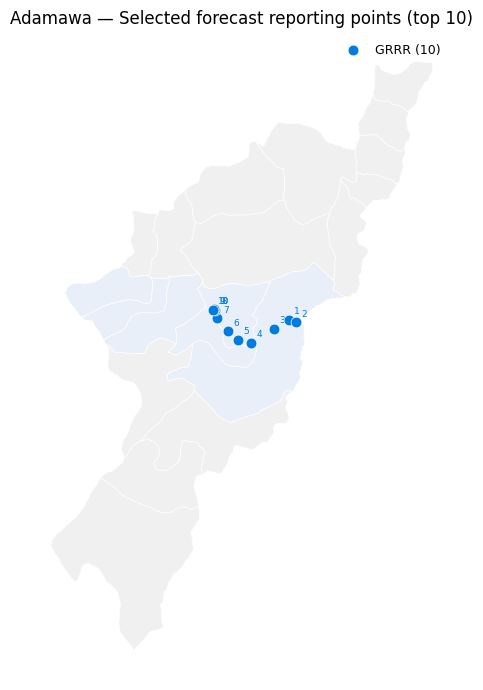

In [11]:
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_state     = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_target    = gdf_lga[gdf_lga["ADM2_PCODE"].isin(cfg["lga_pcodes"])].copy()
gdf_nontarget = gdf_state[~gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]

SOURCE_STYLE = {
    "grrr":   {"color": "#007CE0", "marker": "o", "s": 60},
    "glofas": {"color": "#1EBFB3", "marker": "D", "s": 80},
}

fig, ax = plt.subplots(figsize=(9, 7))
gdf_nontarget.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_target.plot(ax=ax,    color="#E8EFF8", edgecolor="white", linewidth=0.5)

for source, grp in df_selected.groupby("source"):
    style = SOURCE_STYLE[source]
    ax.scatter(
        grp["longitude"], grp["latitude"],
        color=style["color"], marker=style["marker"], s=style["s"],
        zorder=5, edgecolors="white", linewidths=0.5,
        label=f"{'GRRR' if source == 'grrr' else 'GloFAS'} ({len(grp)})",
    )

for rank, row in df_selected.iterrows():
    ax.annotate(
        str(rank + 1),
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points",
        fontsize=6.5, color=SOURCE_STYLE[row["source"]]["color"],
    )

ax.legend(fontsize=9, frameon=False)
ax.set_axis_off()
ax.set_title(f"{STATE} — Selected forecast reporting points (top {TOP_N})", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_selected_gauges_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Save

In [12]:
stratus.upload_parquet_to_blob(df_selected, BLOB_SEL)
print(f"Saved {len(df_selected)} selected gauges to {BLOB_SEL}")

Saved 10 selected gauges to ds-aa-nga-flooding/processed/workflow/adamawa_selected_gauges.parquet
